In [27]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

In [4]:
novagen = pd.read_csv("novagen_dataset.csv")
novagen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [7]:
bool_columns  = novagen.select_dtypes(include="bool").columns
bool_columns

Index(['Diet_Type__Vegan', 'Diet_Type__Vegetarian', 'Blood_Group_AB',
       'Blood_Group_B', 'Blood_Group_O'],
      dtype='object')

In [11]:
novagen[bool_columns] = novagen[bool_columns].astype("int8")
novagen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

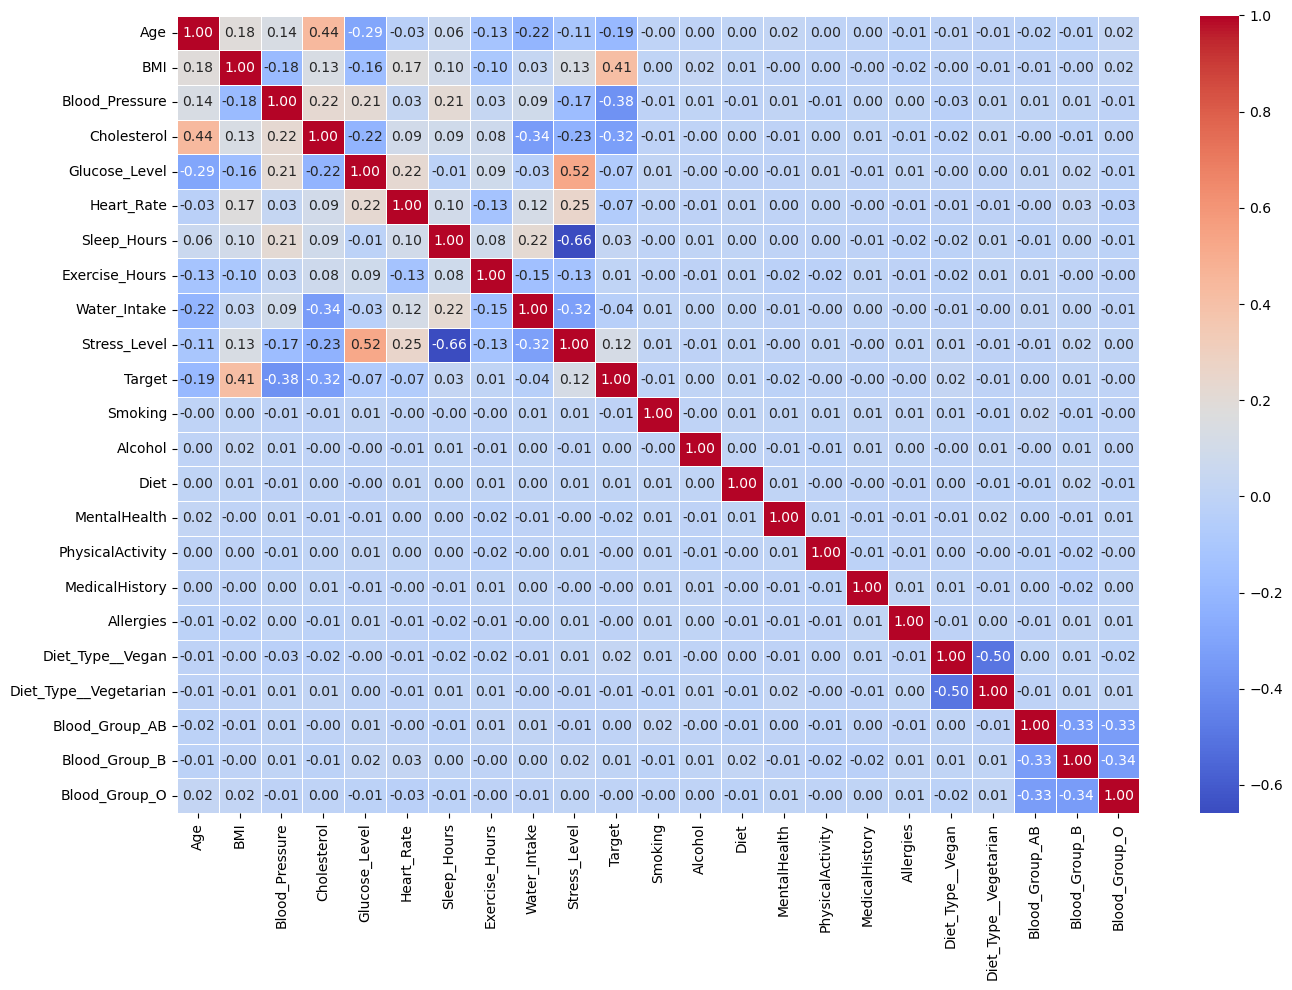

In [20]:
novagen_corr = novagen.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(novagen_corr,annot = True,cmap= "coolwarm",fmt = ".2f",cbar =True,linewidth =0.5)
plt.tight_layout()
plt.show()

In [36]:
x = novagen.drop("Target",axis = 1)
y = novagen["Target"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 42)
clf = DecisionTreeClassifier(max_depth = 4)
model  = BaggingClassifier(estimator = clf,
                          n_estimators = 51,
                          random_state = 42,
                          bootstrap = True)
model.fit(x_train,y_train)



BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                  n_estimators=51, random_state=42)

In [37]:
y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)
print(" Training accuracy_score : ",accuracy_score(y_train,y_pred_train))
print("Testing accuracy_score : ",accuracy_score(y_test,y_pred))

 Training accuracy_score :  0.8402457757296466
Testing accuracy_score :  0.8450586264656617


In [ ]:
# 